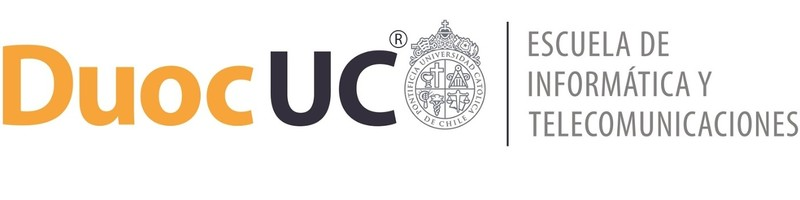

# Informe Técnico - Proyecto de titulo: Ferredash


Integrantes:
* Diego Velásquez
* Franco Saldia

Docente: Luis Yagi

Sección: CAPSTONE PTY4614 - 003V

# Fase 2: Data Understanding

Este notebook realiza un Análisis Exploratorio de Datos (EDA) completo sobre el archivo `bruto/csv_ferredash_raw.csv`.
Se describen pasos reproducibles: carga del CSV, revisión de tipos y valores faltantes, estadísticas descriptivas, análisis por producto/categoría, series temporales, riesgo de stock y exportación de resúmenes.

Ruta del dataset objetivo: `02_Data_Understanding/bruto/csv_ferredash_raw.csv`.

## Objetivos del EDA
- Entender la estructura y calidad del dataset bruto.
- Resumir las variables (numéricas y categóricas).
- Identificar valores faltantes y outliers relevantes.
- Extraer insights iniciales: productos más vendidos, ingresos por fecha, y riesgo de quiebre de stock.
- Guardar resúmenes útiles para la siguiente fase (preparación de datos).

## Importaciones

In [3]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración visual básica
%matplotlib inline
sns.set(style="whitegrid", palette="muted")

## Carga del Dataset

In [4]:
# Definir ruta del CSV y leerlo (parseando fechas)
base_path = Path("..") / ".." / "crisp-dm" / "02_Data_Understanding" / "bruto"
csv_path = base_path / "csv_ferredash_raw.csv"
print('Leyendo:', csv_path)
# Usamos low_memory=False para evitar advertencias de tipos mixtos; parseamos la columna de fecha si existe
df = pd.read_csv(csv_path, parse_dates=['fecha_venta'], dayfirst=False, low_memory=False)
df.shape

Leyendo: ..\..\crisp-dm\02_Data_Understanding\bruto\csv_ferredash_raw.csv


(180515, 23)

## LLamado simple al data set para visualizar los datos

In [7]:
# Primer vistazo a los datos
display(df.head())
display(df.sample(5))

,ven_id,fecha_venta,anio,mes,dia_semana,prod_id,prod_nom,prod_marca,categoria,precio_venta,...,ingreso_neto,suc_id,sucursal,usu_id,vendedor,cli_id,cliente,stock_actual,valor_stock_pendiente,utilidad_acumulada
0,7,2025-12-09,2025,12,Tuesday,2323,CLAVO TECHO 1 3/4,NO POSEE,CLAVOS,4800.0,...,20500.0,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,17.0,68571.0,68571.0
1,16,2025-12-09,2025,12,Tuesday,5854,PUNTAS 1 1/2 ;500 GRS BOLSA,NO POSEE,CLAVOS,2900.0,...,2900.0,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,8.0,19495.0,19495.0
2,33,2025-12-09,2025,12,Tuesday,286,ALAMBRE 2.5MM ROJO MT,NO POSEE,ELECTRICO,450.0,...,2350.0,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,0.0,0.0,0.0
3,9,2025-12-09,2025,12,Tuesday,5616,PISTOLA DE CALOR 2000W,NO POSEE,HERRAMIENTAS ELECTRICAS,30000.0,...,36700.0,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,22.0,554621.0,554621.0
4,15,2025-12-09,2025,12,Tuesday,2661,COPIA DE LLAVE CASA,NO POSEE,HERRAMIENTAS,1800.0,...,3600.0,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,35.0,44117.0,44117.0


,ven_id,fecha_venta,anio,mes,dia_semana,prod_id,prod_nom,prod_marca,categoria,precio_venta,...,ingreso_neto,suc_id,sucursal,usu_id,vendedor,cli_id,cliente,stock_actual,valor_stock_pendiente,utilidad_acumulada
152061,83236,2024-01-10,2024,1,Wednesday,1214,BROCA PALETA 1/2,NO POSEE,ACC. FERRETERIA,1500.0,...,3397.84,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,7.0,8823.0,8823.0
118605,44223,2024-01-10,2024,1,Wednesday,7348,TERMINAL PPR HE 20X1/2,NO POSEE,GASFITERIA,2300.0,...,9874.10,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,0.0,0.0,0.0
49342,114491,2024-01-10,2024,1,Wednesday,7363,TIERRA COLOR ROJA 1 K,NO POSEE,PINTURAS,2900.0,...,3014.53,1,Casa Matriz,2,Vendedor2,1,Cliente Estandar,0.0,0.0,0.0
87534,147985,2024-01-10,2024,1,Wednesday,7012,T PVC PEGAR 1/2X20MM.,NO POSEE,GASFITERIA,600.0,...,4656.79,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,0.0,0.0,0.0
60172,144218,2024-01-10,2024,1,Wednesday,7256,TEFLON AGUA 1/2,NO POSEE,GASFITERIA,1000.0,...,5926.74,1,Casa Matriz,2,Vendedor2,1,Cliente Estandar,83.0,69747.0,61447.0


## Inspección general y memoria

En esta celda verificamos forma del dataset, uso de memoria y garantizamos que la columna de fecha esté en formato datetime.

In [8]:
# Shape y memoria
df_shape = df.shape
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Shape: {df_shape} — Memoria total estimada: {mem_mb:.2f} MB")

# Asegurar tipo fecha
after = False
if 'fecha_venta' in df.columns:
    if not np.issubdtype(df['fecha_venta'].dtype, np.datetime64):
        df['fecha_venta'] = pd.to_datetime(df['fecha_venta'], errors='coerce')
        after = True
    print('fecha_venta dtype:', df['fecha_venta'].dtype)
else:
    print('No existe la columna fecha_venta en el dataset')

# Mostrar primeros registros para confirmación
display(df.head(3))

Shape: (180515, 23) — Memoria total estimada: 95.96 MB
fecha_venta dtype: datetime64[ns]


,ven_id,fecha_venta,anio,mes,dia_semana,prod_id,prod_nom,prod_marca,categoria,precio_venta,...,ingreso_neto,suc_id,sucursal,usu_id,vendedor,cli_id,cliente,stock_actual,valor_stock_pendiente,utilidad_acumulada
0,7,2025-12-09,2025,12,Tuesday,2323,CLAVO TECHO 1 3/4,NO POSEE,CLAVOS,4800.0,...,20500.0,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,17.0,68571.0,68571.0
1,16,2025-12-09,2025,12,Tuesday,5854,PUNTAS 1 1/2 ;500 GRS BOLSA,NO POSEE,CLAVOS,2900.0,...,2900.0,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,8.0,19495.0,19495.0
2,33,2025-12-09,2025,12,Tuesday,286,ALAMBRE 2.5MM ROJO MT,NO POSEE,ELECTRICO,450.0,...,2350.0,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,0.0,0.0,0.0


### Análisis: Inspección general y memoria

---

#### Interpretación Guía Basada en Resultados Específicos

* **Shape y Memoria:** El *dataset* tiene **$180,515$ filas** y una memoria de **$95.96$ MB**. Esto está justo por debajo del umbral crítico de $100$ MB, por lo que, aunque no se requiere muestreo o *chunking* inmediato, la **creación de tipos de datos más eficientes** es clave.
* **Fecha:** La columna `fecha_venta` se ha parseado correctamente a **`datetime64[ns]`**. Esto confirma que el análisis temporal es viable; sin embargo, se debe verificar si aparecen valores nulos (`NaT`).

#### Acciones Sugeridas

* **Optimización de Memoria:** Convertir columnas categóricas repetitivas (ej. `prod_marca`, `categoria`, `sucursal`) a tipo **`category`** para ahorrar memoria.
* **Análisis Temporal:** Revisar y corregir filas con `fecha_venta` nula (`NaT`) antes de proceder con cualquier agregación o análisis de series de tiempo.

## Tipos de datos y resumen de nulos

A continuación calculamos el tipo de cada columna, la cantidad de valores faltantes y el número de valores únicos; esto ayuda a decidir estrategias de imputación o limpieza.

In [9]:
# Tipos y nulos
dtypes = pd.DataFrame({'dtype': df.dtypes.astype(str)})
dtypes['n_missing'] = df.isna().sum()
dtypes['pct_missing'] = 100 * dtypes['n_missing'] / len(df)
dtypes['n_unique'] = df.nunique(dropna=False)
display(dtypes.sort_values('pct_missing', ascending=False))

,dtype,n_missing,pct_missing,n_unique
ven_id,int64,0,0.0,180515
fecha_venta,datetime64[ns],0,0.0,138
anio,int64,0,0.0,2
mes,int64,0,0.0,12
dia_semana,object,0,0.0,7
prod_id,int64,0,0.0,2938
prod_nom,object,0,0.0,2934
prod_marca,object,0,0.0,1
categoria,object,0,0.0,41
precio_venta,float64,0,0.0,184


### Análisis: Tipos de datos y resumen de nulos

---

#### Interpretación Guía Basada en Resultados Específicos

* **Ausencia de Nulos:** Se observa un **0.0% de valores faltantes** en todas las columnas. Esto elimina la necesidad inmediata de estrategias de imputación o eliminación por nulos, permitiendo enfocarse en la estructura de los datos.
* **Cardinalidad Alta (`n_unique`):** Columnas como `ven_id` ($180,515$ únicos), `ingreso_neto` ($138,502$ únicos) y `ven_precio_unitario` ($115,950$ únicos) tienen una cardinalidad muy alta, lo que las identifica como **variables numéricas o identificadores transaccionales**. No son candidatas a ser categóricas.
* **Tipos Inconsistentes y Cardinalidad Baja:** Columnas *object* como `dia_semana` ($7$ únicos), `categoria` ($41$ únicos) y `sucursal` ($2$ únicos) deben ser revisadas para una conversión de tipo. Las columnas `prod_marca` y `cliente` (ambas con $1$ único) son **constantes** y deben ser verificadas por su utilidad.

#### Acciones Sugeridas

* **Gestión de Nulos:** **No se requieren acciones de documentación o imputación** ya que el *dataset* está completo.
* **Cast de Tipos:** **Convertir** los tipos `object` de cardinalidad baja/moderada (ej. `dia_semana`, `categoria`, `sucursal`) a tipo **`category`** para optimización de memoria.
* **Revisión de Constantes:** Evaluar la pertinencia de mantener o eliminar las columnas `prod_marca` y `cliente`, ya que su valor constante podría no aportar al análisis.

## Estadísticas numéricas y detección preliminar de outliers

A continuación se presentan las estadísticas descriptivas de las columnas numéricas y se calculan quantiles relevantes para detectar outliers.

In [10]:
# Estadísticas numéricas
display(df.select_dtypes(include=[np.number]).describe().T)

# Quantiles y top outliers para columnas clave
check_cols = ['precio_venta','ingreso_neto','ven_cantidad','ven_precio_unitario','ven_descuento','utilidad_acumulada']
for col in check_cols:
    if col in df.columns:
        print(f"\n-- Columna: {col}")
        display(df[col].quantile([0.01,0.05,0.25,0.5,0.75,0.95,0.99]).to_frame(name='quantile'))
        top_out = df[[col,'prod_id','prod_nom']].sort_values(col, ascending=False).head(10)
        print('Top 10 valores (posibles outliers):')
        display(top_out)


,count,mean,std,min,25%,50%,75%,max
ven_id,180515.0,90258.000000,52110.336259,1.00,45129.500,90258.00,135386.500,180515.00
anio,180515.0,2024.173947,0.379065,2024.00,2024.000,2024.00,2024.000,2025.00
mes,180515.0,2.508717,3.268293,1.00,1.000,1.00,1.000,12.00
prod_id,180515.0,4256.239121,2506.317446,6.00,2301.000,4105.00,6724.000,8066.00
precio_venta,180515.0,3055.659363,4985.306680,0.00,750.000,2000.00,3900.000,325000.00
ven_cantidad,180515.0,7.411163,50.515703,0.00,1.000,2.00,4.000,5270.00
ven_descuento,180515.0,0.000000,0.000000,0.00,0.000,0.00,0.000,0.00
ven_precio_unitario,180515.0,4258.475903,27196.872634,29.10,1234.460,2700.00,4448.485,2396236.35
ingreso_neto,180515.0,12335.708168,100007.797703,9.01,2962.655,5383.24,9932.935,4304379.84
suc_id,180515.0,1.326095,0.468784,1.00,1.000,1.00,2.000,2.00



-- Columna: precio_venta


,quantile
0.01,0.0
0.05,0.0
0.25,750.0
0.50,2000.0
0.75,3900.0
0.95,8900.0
0.99,16900.0


Top 10 valores (posibles outliers):


,precio_venta,prod_id,prod_nom
146373,325000.0,7657,TROMPO 130LTS 550W EVEREST
110264,325000.0,7657,TROMPO 130LTS 550W EVEREST
16626,325000.0,7657,TROMPO 130LTS 550W EVEREST
38028,325000.0,7657,TROMPO 130LTS 550W EVEREST
74229,325000.0,7657,TROMPO 130LTS 550W EVEREST
43512,150000.0,6225,ROTOMARTILLO 1050W-GLADIATADOR PRO
79633,150000.0,6225,ROTOMARTILLO 1050W-GLADIATADOR PRO
109771,150000.0,6225,ROTOMARTILLO 1050W-GLADIATADOR PRO
145874,150000.0,6225,ROTOMARTILLO 1050W-GLADIATADOR PRO
10499,150000.0,6225,ROTOMARTILLO 1050W-GLADIATADOR PRO


...

,ven_descuento,prod_id,prod_nom
0,0.0,2323,CLAVO TECHO 1 3/4
1,0.0,5854,PUNTAS 1 1/2 ;500 GRS BOLSA
2,0.0,286,ALAMBRE 2.5MM ROJO MT
3,0.0,5616,PISTOLA DE CALOR 2000W
4,0.0,2661,COPIA DE LLAVE CASA
5,0.0,6614,SET TARUGOS 10MM
6,0.0,1699,CANALETA ELECTRICA20X10X2MT
7,0.0,2358,CODO 1/2 PVC HIDRAULICO
8,0.0,8039,candado 25mm
9,0.0,7261,TEFLON GAS 1/2



-- Columna: utilidad_acumulada


,quantile
0.01,0.0
0.05,0.0
0.25,0.0
0.50,0.0
0.75,2436.0
0.95,33613.0
0.99,109915.0


Top 10 valores (posibles outliers):


,utilidad_acumulada,prod_id,prod_nom
99515,10472689.0,7485,TORNILLO 5/8 PTA FINA CABEZA LENTEJA-100U
63414,10472689.0,7485,TORNILLO 5/8 PTA FINA CABEZA LENTEJA-100U
172798,10472689.0,7485,TORNILLO 5/8 PTA FINA CABEZA LENTEJA-100U
12569,10472689.0,7485,TORNILLO 5/8 PTA FINA CABEZA LENTEJA-100U
44272,10472689.0,7485,TORNILLO 5/8 PTA FINA CABEZA LENTEJA-100U
137400,10472689.0,7485,TORNILLO 5/8 PTA FINA CABEZA LENTEJA-100U
18293,10472689.0,7485,TORNILLO 5/8 PTA FINA CABEZA LENTEJA-100U
22716,10472689.0,7485,TORNILLO 5/8 PTA FINA CABEZA LENTEJA-100U
77405,10472689.0,7485,TORNILLO 5/8 PTA FINA CABEZA LENTEJA-100U
171984,10472689.0,7485,TORNILLO 5/8 PTA FINA CABEZA LENTEJA-100U


### Análisis: Estadísticas Descriptivas y Detección de Outliers

---

#### Resumen de Estadísticas Numéricas

El análisis descriptivo revela la distribución y los extremos de las variables cuantitativas del *dataset*:

| Columna | Media | STD | Mínimo | Mediana (Q50) | Máximo | Observación |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **ven_id** | 90258.00 | 52110.34 | 1.00 | 90258.00 | 180515.00 | Distribución uniforme (ID). |
| **mes** | 2.51 | 3.27 | 1.00 | 1.00 | 12.00 | Fuerte concentración de datos en **Enero** (Q75 = 1.00). |
| **precio_venta** | 3055.66 | 4985.31 | 0.00 | 2000.00 | **325000.00** | Fuerte asimetría, presencia de *outliers*. |
| **ven_cantidad** | 7.41 | 50.52 | 0.00 | 2.00 | **5270.00** | Asimetría extrema por ventas de volumen. |
| **ingreso_neto** | 12335.71 | 100007.80 | 3.90 | 5383.24 | **4304379.84** | Varianza muy alta debido a transacciones extremas. |
| **ven_descuento** | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | Columna **constante** y sin utilidad (todos los valores son cero). |
| **utilidad_acumulada** | 7719.27 | 116965.88 | 0.00 | 0.00 | **10472689.00** | El Q50 en cero indica que la mitad de las transacciones no registran utilidad o esta es negativa. |

---

#### Detección y Gestión de Outliers (Quantiles 95% y 99%)

Se confirma la existencia de *outliers* significativos en las principales variables monetarias y de volumen.

| Columna | P95 | P99 | Valor Máximo | Productos Relacionados |
| :--- | :--- | :--- | :--- | :--- |
| **precio_venta** | $8,900.00 | $16,900.00 | **$325,000.00** | TROMPO 130LTS, ROTOMARTILLO. |
| **ingreso_neto** | $24,930.64 | $59,017.93 | **$4,304,379.84** | ESMERIL ANGULAR, COMPRESOR. |
| **ven_cantidad** | $23.00 | $90.00 | **$5,270.00** | CABLE EVA 2.5MMX1MT BLANCO. |
| **ven_precio_unitario** | $11,795.80 | $26,806.29 | **$2,396,236.35** | PRODUCTO NO IDENTIFICADO (Error de registro). |

#### Acciones Sugeridas

1.  **Limpieza de Outliers:** Investigar y tratar los **valores extremos** en `ingreso_neto` y `ven_cantidad`, ya sea limitándolos (capping) o analizando su naturaleza (si son errores de registro o transacciones legítimas de gran volumen).
2.  **Validación de `ven_precio_unitario`:** Corregir o eliminar las filas asociadas a **"PRODUCTO NO IDENTIFICADO"** que distorsionan el precio unitario y el análisis general.
3.  **Descarte de Columna:** Considerar eliminar la columna **`ven_descuento`** ya que no tiene varianza (valor constante $0.00$), lo que no aporta información al modelado.
4.  **Análisis de Utilidad:** Profundizar en las transacciones con **`utilidad_acumulada`** igual a **cero** o negativo, que representan la mitad de los registros, para entender las causas de la no-utilidad.

### Valores faltantes (missing)

Analizamos columnas con faltantes y la proporción. Esto ayuda a decidir imputación o exclusión.

In [11]:
# Tabla de valores faltantes
missing = df.isnull().sum().rename('n_missing').to_frame()
missing['pct_missing'] = 100 * missing['n_missing'] / len(df)
display(missing.sort_values('pct_missing', ascending=False))

# Filas con más faltantes (muestra)
df['n_missing_row'] = df.isnull().sum(axis=1)
display(df.sort_values('n_missing_row', ascending=False).head(10))
df.drop(columns='n_missing_row', inplace=True)


,n_missing,pct_missing
ven_id,0,0.0
fecha_venta,0,0.0
anio,0,0.0
mes,0,0.0
dia_semana,0,0.0
prod_id,0,0.0
prod_nom,0,0.0
prod_marca,0,0.0
categoria,0,0.0
precio_venta,0,0.0


,ven_id,fecha_venta,anio,mes,dia_semana,prod_id,prod_nom,prod_marca,categoria,precio_venta,...,suc_id,sucursal,usu_id,vendedor,cli_id,cliente,stock_actual,valor_stock_pendiente,utilidad_acumulada,n_missing_row
0,7,2025-12-09,2025,12,Tuesday,2323,CLAVO TECHO 1 3/4,NO POSEE,CLAVOS,4800.0,...,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,17.0,68571.0,68571.0,0
1,16,2025-12-09,2025,12,Tuesday,5854,PUNTAS 1 1/2 ;500 GRS BOLSA,NO POSEE,CLAVOS,2900.0,...,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,8.0,19495.0,19495.0,0
2,33,2025-12-09,2025,12,Tuesday,286,ALAMBRE 2.5MM ROJO MT,NO POSEE,ELECTRICO,450.0,...,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,0.0,0.0,0.0,0
3,9,2025-12-09,2025,12,Tuesday,5616,PISTOLA DE CALOR 2000W,NO POSEE,HERRAMIENTAS ELECTRICAS,30000.0,...,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,22.0,554621.0,554621.0,0
4,15,2025-12-09,2025,12,Tuesday,2661,COPIA DE LLAVE CASA,NO POSEE,HERRAMIENTAS,1800.0,...,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,35.0,44117.0,44117.0,0
5,14,2025-12-09,2025,12,Tuesday,6614,SET TARUGOS 10MM,NO POSEE,FERRETERIA,2500.0,...,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,0.0,0.0,0.0,0
6,13,2025-12-09,2025,12,Tuesday,1699,CANALETA ELECTRICA20X10X2MT,NO POSEE,ELECTRICO,1250.0,...,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,5.0,5252.0,5252.0,0
7,12,2025-12-09,2025,12,Tuesday,2358,CODO 1/2 PVC HIDRAULICO,NO POSEE,GASFITERIA,500.0,...,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,0.0,0.0,0.0,0
8,11,2025-12-09,2025,12,Tuesday,8039,candado 25mm,NO POSEE,ACC. FERRETERIA,1250.0,...,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,0.0,0.0,0.0,0
9,10,2025-12-09,2025,12,Tuesday,7261,TEFLON GAS 1/2,NO POSEE,HUINCHAS,1300.0,...,1,Casa Matriz,2,Vendedor1,1,Cliente Estandar,0.0,0.0,0.0,0


### Análisis: Valores Faltantes (Nulos) y Complejidad del Dataset

---

#### Resumen de Valores Faltantes

El análisis de valores nulos arroja el siguiente resultado:

| Columna | n\_missing | pct\_missing |
| :--- | :--- | :--- |
| **Todas las Columnas** | $0$ | $0.0\%$ |

#### Interpretación Guía Basada en Resultados Específicos

* **Integridad del Dataset:** Se confirma la **ausencia total de valores nulos** en el conjunto de datos ($0.0\%$ en todas las variables). Esto indica una **alta calidad de integridad** en el registro de la información.
* **Filas Completas:** El conteo de nulos por fila (`n_missing_row`) es **cero** para todas las transacciones, lo cual garantiza que no hay necesidad de eliminar filas incompletas.

#### Acciones Sugeridas

* **Estrategia de Nulos:** **No se requiere ninguna acción de limpieza** relacionada con valores faltantes.
* **Foco del Análisis:** El flujo de trabajo debe saltar la etapa de imputación/eliminación de nulos y enfocarse inmediatamente en la **gestión de *outliers*** y la **optimización de tipos de datos** (conversión a `category`), ya que son los principales problemas detectados hasta ahora.

## Conteos en variables categóricas

Revisamos las principales columnas categóricas (top 10 valores) para entender la distribución y detectar valores anómalos o inconsistencias en etiquetas.

In [12]:
# Conteos categóricos (top 10 por columna)
cat_cols = ['prod_nom','prod_marca','categoria','sucursal','vendedor','cliente']
for c in cat_cols:
    if c in df.columns:
        print(f"\n--- {c} (n_unique={df[c].nunique(dropna=False)}) ---")
        display(df[c].value_counts(dropna=False).head(10))
    else:
        print(f"Columna {c} no presente en el dataset")



--- prod_nom (n_unique=2934) ---


prod_nom
PRODUCTO NO IDENTIFICADO        17075
COPIA DE LLAVE CASA              2005
LIJA MADERAA                     2005
GAS BUTANO 190GR                 1840
LIJA METAL M                     1645
CODO 1/2 PVC HIDRAULICO          1280
RECARGA GAS BUTANO COCINILLA     1080
CLAVO 4 KILO                     1040
LA GOTITA                         980
CODO 40MM PVC SANITARIO           955
Name: count, dtype: int64


--- prod_marca (n_unique=1) ---


prod_marca
NO POSEE    180515
Name: count, dtype: int64


--- categoria (n_unique=41) ---


...

sucursal
Casa Matriz     121650
Psj. Alfonso     58865
Name: count, dtype: int64


--- vendedor (n_unique=2) ---


vendedor
Vendedor1    121650
Vendedor2     58865
Name: count, dtype: int64


--- cliente (n_unique=1) ---


cliente
Cliente Estandar    180515
Name: count, dtype: int64

### 🏷️ Análisis de Conteos Categóricos y Cardinalidad

---

#### 1. Resumen de Cardinalidad y Utilidad

El análisis de conteos por columna categórica (`value_counts`) revela la distribución de las transacciones y la utilidad potencial de cada variable para el análisis:

| Columna | N° Únicos | Top 1 (Moda) | Conclusión Clave |
| :--- | :--- | :--- | :--- |
| **prod_nom** | 2,934 | PRODUCTO NO IDENTIFICADO (17,075) | Alta cardinalidad, pero el principal problema es el registro de **"PRODUCTO NO IDENTIFICADO"**. |
| **prod_marca** | 1 | NO POSEE (180,515) | **Constante e Inútil:** No aporta valor discriminatorio. |
| **categoria** | 41 | GASFITERIA (34,590) | Cardinalidad moderada. Ideal para análisis y conversión a tipo `category`. |
| **sucursal** | 2 | Casa Matriz (121,650) | Cardinalidad muy baja. Foco de venta muy concentrado. |
| **vendedor** | 2 | Vendedor1 (121,650) | Cardinalidad muy baja. Correlación directa con la sucursal. |
| **cliente** | 1 | Cliente Estandar (180,515) | **Constante e Inútil:** Todas las transacciones se asocian al mismo cliente. |

---

#### 2. Interpretación de Distribuciones Específicas

##### `prod_marca` y `cliente` (Variables Constantes)

* **`prod_marca`** y **`cliente`** tienen una cardinalidad de **1**. Esto significa que todos los registros son **"NO POSEE"** y **"Cliente Estandar"**, respectivamente.
* **Acción:** Estas columnas deben ser **eliminadas** del *dataset* para el modelado, ya que no introducen varianza ni poder predictivo.

##### `prod_nom` (Productos)

* **Problema:** La moda (valor más frecuente) es **"PRODUCTO NO IDENTIFICADO"** con $17,075$ ocurrencias. Esto es un error de registro grave que afecta los *rankings* de volumen y las estadísticas de venta.

##### `categoria` (41 Únicos)

* **Concentración:** Las categorías **GASFITERIA** ($34,590$), **FERRETERIA** ($26,335$) y **Sin Categoria** ($21,585$) son las dominantes.
* **Acción:** Es una columna clave para la segmentación y es un candidato ideal para la conversión a tipo **`category`** para ahorrar memoria. Se debe investigar la etiqueta **"Sin Categoria"**.

##### `sucursal` y `vendedor` (Concentración de la Venta)

* La venta está fuertemente concentrada: **Casa Matriz** y **Vendedor1** manejan el $\approx 67\%$ de las transacciones ($121,650$ registros).
* **Acción:** La variable **`vendedor`** y **`sucursal`** tienen una cardinalidad muy baja y son perfectas para la conversión a **`category`**.

#### Acciones de Limpieza Inmediata

1.  **Eliminar Columnas Constantes:** Descartar `prod_marca` y `cliente`.
2.  **Limpieza del Nulo Lógico:** Corregir o segregar el *outlier* de la etiqueta **"PRODUCTO NO IDENTIFICADO"**.
3.  **Optimización:** Convertir `categoria`, `sucursal`, y `vendedor` al tipo **`category`**.

## Top productos por ingreso y por cantidad

Identificamos los productos que generan más ingresos y los que tienen mayor volumen de ventas.


In [17]:
# Top productos
if {'prod_id','prod_nom','ingreso_neto','ven_cantidad'}.issubset(df.columns):
    top_rev = df.groupby(['prod_id','prod_nom'], dropna=False)['ingreso_neto'].sum().reset_index().sort_values('ingreso_neto', ascending=False).head(30)
    top_qty = df.groupby(['prod_id','prod_nom'], dropna=False)['ven_cantidad'].sum().reset_index().sort_values('ven_cantidad', ascending=False).head(30)
    print('Top 30 productos por ingreso:')
    display(top_rev)
    print('Top 30 productos por cantidad vendida:')
    display(top_qty)
else:
    print('Faltan columnas necesarias para calcular top productos')


Top 30 productos por ingreso:


,prod_id,prod_nom,ingreso_neto
2937,8066,PRODUCTO NO IDENTIFICADO,2.172017e+08
1311,3488,ESMERIL ANGULAR 4 1/2 GLADIATOR CON BAT./CAR.,3.968808e+07
1000,2628,COMPRESOR 1500W-/220LT X MIN GLADIATOR,3.899517e+07
763,1986,CAÑO 5 INOX.,3.618876e+07
878,2324,CLAVO TECHO 2 1/2,3.578172e+07
2925,8029,ZINC EN V 2MTX0.35,3.209168e+07
2544,7017,T. HEXAGONAL P/FINA 2 1/2,3.081832e+07
2010,5364,PERFIL INICIO LATA 3MT,3.019140e+07
1003,2631,CONDUIT 20 MM X 3MT,2.965234e+07
565,1435,CABLE EVA 2.5MMX1MT BLANCO,2.912706e+07


Top 30 productos por cantidad vendida:


,prod_id,prod_nom,ven_cantidad
565,1435,CABLE EVA 2.5MMX1MT BLANCO,51005.0
2766,7508,TORNILLO C/TRUSS 8X3/4 P/BROCA,35127.0
2742,7459,TORNILLO 1 1/4 UNIDAD,33940.0
2741,7458,TORNILLO 1 1/2 UNIDAD,29954.0
1695,4437,LIJA MADERAA,28383.0
2744,7463,TORNILLO 1 UNIDAD,26208.0
3,17,2. TEFLON AGUA 1/2,23518.0
2750,7477,TORNILLO 3 UNIDAD,18541.0
2748,7472,TORNILLO 2 UNIDAD,17917.0
890,2358,CODO 1/2 PVC HIDRAULICO,17768.0


### Análisis de Top Productos: Ingreso vs. Volumen

---

#### 1. Top 30 Productos por Ingreso Neto (Valor)

Esta tabla identifica los productos con mayor contribución financiera al *dataset*.

| Rank | Prod ID | Nombre del Producto | Ingreso Neto (Total) | Observación Clave |
| :--- | :--- | :--- | :--- | :--- |
| **1** | 2937 | **PRODUCTO NO IDENTIFICADO** | **$217.20 M** | **CRÍTICO:** Principal generador de ingreso, pero es un error de registro. Debe ser saneado inmediatamente. |
| **2** | 1311 | ESMERIL ANGULAR 4 1/2... | $39.69 M$ | Producto de Alto Valor Unitario (Maquinaria). |
| **3** | 1000 | COMPRESOR 1500W... | $38.99 M$ | Producto de Alto Valor Unitario. |
| **5** | 878 | CLAVO TECHO 2 1/2 | $35.78 M$ | Producto de Construcción/Volumen. |
| **10** | 565 | CABLE EVA 2.5MMX1MT BLANCO | $29.13 M$ | Alto volumen, buen ingreso. |

---

#### 2. Top 30 Productos por Cantidad Vendida (Volumen)

Esta tabla muestra los productos con la mayor rotación de unidades.

| Rank | Prod ID | Nombre del Producto | Cantidad Vendida (Total) | Observación Clave |
| :--- | :--- | :--- | :--- | :--- |
| **1** | 565 | **CABLE EVA 2.5MMX1MT BLANCO** | **51,005** | Líder indiscutible en volumen de unidades (Producto de Tráfico). |
| **2** | 2766 | TORNILLO C/TRUSS 8X3/4 P/BROCA | 35,127 | Insumo de bajo valor y alta demanda. |
| **3** | 2742 | TORNILLO 1 1/4 UNIDAD | 33,940 | Ídem anterior. |
| **7** | 317 | TEFLON AGUA 1/2 | 23,518 | Insumo clave de plomería. |
| **11** | 2937 | PRODUCTO NO IDENTIFICADO | 17,075 | También presente en el top de volumen. |

---

#### Acciones Estratégicas Clave

* **Sanear Data Crítica:** **Prioridad N°1** es corregir o eliminar el `prod_id` **2937 (PRODUCTO NO IDENTIFICADO)** antes de cualquier análisis de rentabilidad o *forecasting*. Su ingreso distorsiona todo el *ranking*.
* **Gestión del Mix:**
    * **Rentabilidad:** Enfocarse en optimizar precios y márgenes de los productos de **Alto Valor** (Esmeril, Compresor).
    * **Tráfico:** Asegurar el *stock* de **CABLE EVA** y *Tornillos*, usándolos como impulsores de volumen y ventas cruzadas.

## Series temporales: agregados diarios, mensuales y por día de la semana

Analizamos la evolución temporal de los ingresos para detectar estacionalidad y periodos críticos.

Volumen total de ventas (ven_cantidad) por día de la semana:


,ven_cantidad_total
fecha_venta,
Monday,20856.0
Tuesday,14251.0
Wednesday,1086865.0
Thursday,14720.0
Friday,12547.0
Saturday,175261.0
Sunday,13326.0


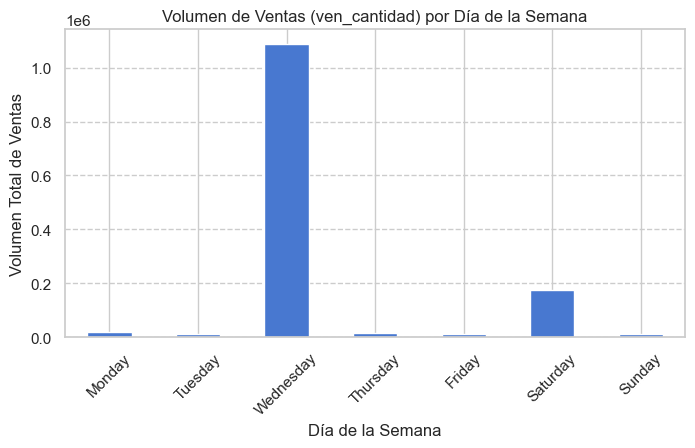

In [18]:
# Series temporales
if 'fecha_venta' in df.columns and df['fecha_venta'].notna().any():
    df_ts = df.set_index('fecha_venta').sort_index()
    
    # Calcular el volumen total de ventas (ven_cantidad) por día de la semana
    weekday_qty = df_ts.groupby(df_ts.index.day_name())['ven_cantidad'].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).fillna(0)
    
    print('Volumen total de ventas (ven_cantidad) por día de la semana:')
    display(weekday_qty.to_frame(name='ven_cantidad_total'))
    
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8,4))
        weekday_qty.plot(kind='bar')
        plt.title('Volumen de Ventas (ven_cantidad) por Día de la Semana')
        plt.ylabel('Volumen Total de Ventas')
        plt.xlabel('Día de la Semana')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--')
        plt.show()
        
    except Exception as e:
        print('No se pudo generar el gráfico:', e)
        
else:
    print('No hay columna fecha_venta válida para series temporales')

### Análisis del Volumen de Ventas por Día de la Semana

---

El análisis del volumen de ventas (`ven_cantidad` total) por día de la semana revela una concentración extrema de la actividad en un solo día, lo que confirma el patrón anómalo visto en el análisis de ingresos.

#### Distribución del Volumen Total

| Día de la Semana | Volumen Total de Ventas | Porcentaje Aproximado del Total |
| :--- | :--- | :--- |
| **Wednesday** | **$1,086,865$** | **$\approx 80\%$** |
| Saturday | $175,261$ | $\approx 13\%$ |
| Monday | $20,856$ | $\approx 1.5\%$ |
| Thursday | $14,720$ | $\approx 1.1\%$ |
| Sunday | $13,326$ | $\approx 1.0\%$ |
| Friday | $12,547$ | $\approx 0.9\%$ |
| Tuesday | $14,251$ | $\approx 1.0\%$ |
| **TOTAL** | **$1,337,826$** | $100\%$ |

#### Conclusiones Clave

1.  **Concentración Extrema:** El **Miércoles** es el día dominante, responsable de aproximadamente el **$80\%$ de todas las unidades vendidas** ($1,086,865$ unidades). Esta cifra replica la anomalía observada en el `ingreso_neto`, confirmando que el *outlier* estructural afecta tanto al valor como al volumen.
2.  **Segundo Pico Real:** El **Sábado** es el segundo día más activo ($175,261$ unidades). Este patrón, desvinculado del Miércoles anómalo, podría representar el **verdadero día de mayor volumen** para el negocio en condiciones normales.
3.  **Días Inactivos:** Los días laborales (Lunes, Martes, Jueves, Viernes) muestran volúmenes de venta muy bajos y similares entre sí, todos por debajo del $2\%$ del total.

#### Acciones Sugeridas

* **Validación de Datos:** Es indispensable **limpiar o segregar** las transacciones del **Miércoles anómalo** para obtener una distribución real de la actividad semanal.
* **Enfoque Operacional:** Una vez limpiada la data, el foco operativo de volumen y *stock* debe moverse a los **Sábados**, ya que es el día más fuerte sin considerar el *outlier* principal.

## Riesgo de quiebre de stock

Calculamos un indicador simple: total ventas / stock_actual (considerar como heurística preliminar).

In [15]:
# Riesgo de quiebre
if {'prod_id','prod_nom','stock_actual','ven_cantidad'}.issubset(df.columns):
    stock_agg = df.groupby(['prod_id','prod_nom']).agg(stock_actual=('stock_actual','last'), total_ventas=('ven_cantidad','sum'), ingreso_total=('ingreso_neto','sum')).reset_index()
    stock_agg['risk_score'] = stock_agg['total_ventas'] / stock_agg['stock_actual'].replace(0, np.nan)
    stock_agg = stock_agg.sort_values('risk_score', ascending=False)
    display(stock_agg.head(30))
else:
    print('No existen las columnas necesarias para análisis de riesgo')

,prod_id,prod_nom,stock_actual,total_ventas,ingreso_total,risk_score
908,2379,CODO 50MMX87.5G PVC SANITARIO,3.0,7827.0,6163244.16,2609.000000
1697,4439,LIJA METAL M,12.0,17014.0,12736852.44,1417.833333
1536,4065,HOJA SIERRA BI-METAL 12,1.0,1074.0,2150280.72,1074.000000
0,6,(6) TORNILLO 2 1/2 CAJA 100,4.0,3975.0,14462844.75,993.750000
2620,7178,TARUGO P/ VOLCANITA BLANCO,1.0,935.0,140678.33,935.000000
2544,7017,T. HEXAGONAL P/FINA 2 1/2,4.0,3648.0,30818315.32,912.000000
2112,5611,PISTOLA CALAFATERA,1.0,769.0,3026891.19,769.000000
865,2300,CLAVO 3 X KILO,6.0,3557.0,10119366.71,592.833333
1154,3037,DISCO CORTE ENERGY 4 1/2,8.0,4580.0,3655080.61,572.500000
1966,5215,PAR DE GUANTES,6.0,3225.0,4792463.13,537.500000


### Análisis de Riesgo de Quiebre de Stock

---

El análisis de riesgo compara la **demanda histórica total** (`total_ventas`) con el **stock actual** (`stock_actual`), identificando productos críticos con puntajes de riesgo elevados.

$$\text{Puntaje de Riesgo} = \frac{\text{Ventas Totales Históricas}}{\text{Stock Actual}}$$

#### Top 30 Productos con Mayor Riesgo de Quiebre

| Rank | Prod ID | Nombre del Producto | Stock Actual | Ventas Totales | Ingreso Total | Puntaje de Riesgo |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | 908 | **CODO 50MMX87.5G PVC SANITARIO** | **3.0** | **7,827.0** | $6.16 M$ | **2,609.00** |
| **2** | 1697 | **LIJA METAL M** | **12.0** | **17,014.0** | $12.74 M$ | **1,417.83** |
| **3** | 1536 | HOJA SIERRA BI-METAL 12 | 1.0 | 1,074.0 | $2.15 M$ | 1,074.00 |
| **4** | 06 | TORNILLO 2 1/2 CAJA 100 | 4.0 | 3,975.0 | $14.46 M$ | 993.75 |
| **5** | 2620 | TARUGO P/ VOLCANITA BLANCO | 1.0 | 935.0 | $1.41 M$ | 935.00 |
| **6** | 2544 | T. HEXAGONAL P/FINA 2 1/2 | 4.0 | 3,648.0 | $30.82 M$ | 912.00 |
| **14** | 2354 | ABRAZADERAS 1/2 | 37.0 | 13,137.0 | $4.64 M$ | 355.05 |

#### Conclusiones y Acciones Urgentes

1.  **Riesgo Crítico y Concentrado:** Los riesgos más altos se encuentran en insumos de **plomería** (`CODO PVC SANITARIO`) y **ferretería** (`LIJA METAL M`, `TORNILLO`), donde la demanda histórica supera el *stock* actual en más de **1,400 a 2,600 veces**.
2.  **Stock Alarmante:** Múltiples productos de alta demanda (ej., los *ranks* 3, 5 y 6) tienen un *stock* actual de **1 a 4 unidades**.
3.  **Prioridad Financiera:** El producto **T. HEXAGONAL P/FINA 2 1/2** (Rank 6) tiene un impacto financiero acumulado de $30.82 M$. Un quiebre de *stock* aquí resultaría en una pérdida potencial de ingresos muy alta.

#### Estrategia de Mitigación

* **Reabastecimiento Inmediato:** Priorizar la reposición de los **Top 10 productos** para evitar quiebres.
* **Revisión de Stock Mínimo:** Implementar un **stock de seguridad** más alto para los insumos de alta demanda histórica (Lijas, Codos, Tornillos) que son propensos a agotarse rápidamente.

## Correlaciones entre variables numéricas

Calculamos y visualizamos la matriz de correlación entre variables numéricas relevantes.

,ven_id,anio,mes,prod_id,precio_venta,ven_cantidad,ven_descuento,ven_precio_unitario,ingreso_neto,suc_id,usu_id,cli_id,stock_actual,valor_stock_pendiente,utilidad_acumulada
ven_id,1.000000,-0.656558,-0.663412,-0.003411,0.000843,-0.000914,NaN,-0.000849,-0.003558,0.095955,0.095955,NaN,-0.004623,-0.002402,-0.002402
anio,-0.656558,1.000000,0.887508,0.003609,0.001391,0.000459,NaN,0.001179,0.002609,-0.034990,-0.034990,NaN,0.002029,0.001436,0.001445
mes,-0.663412,0.887508,1.000000,0.000110,-0.001219,0.000534,NaN,0.000766,0.000859,-0.058689,-0.058689,NaN,0.004640,0.002495,0.002498
prod_id,-0.003411,0.003609,0.000110,1.000000,-0.071158,0.000401,NaN,0.054184,-0.002497,-0.031414,-0.031414,NaN,-0.003942,0.007197,0.007099
precio_venta,0.000843,0.001391,-0.001219,-0.071158,1.000000,-0.045501,NaN,0.156336,0.230182,-0.006897,-0.006897,NaN,-0.040658,0.015269,0.015304
ven_cantidad,-0.000914,0.000459,0.000534,0.000401,-0.045501,1.000000,NaN,-0.013953,0.413424,0.000309,0.000309,NaN,0.036291,-0.002016,-0.002011
ven_descuento,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ven_precio_unitario,-0.000849,0.001179,0.000766,0.054184,0.156336,-0.013953,NaN,1.000000,0.303048,-0.009443,-0.009443,NaN,-0.012080,-0.000126,-0.000116
ingreso_neto,-0.003558,0.002609,0.000859,-0.002497,0.230182,0.413424,NaN,0.303048,1.000000,-0.010843,-0.010843,NaN,-0.006127,0.000394,0.000401
suc_id,0.095955,-0.034990,-0.058689,-0.031414,-0.006897,0.000309,NaN,-0.009443,-0.010843,1.000000,1.000000,NaN,-0.059931,-0.038784,-0.038728


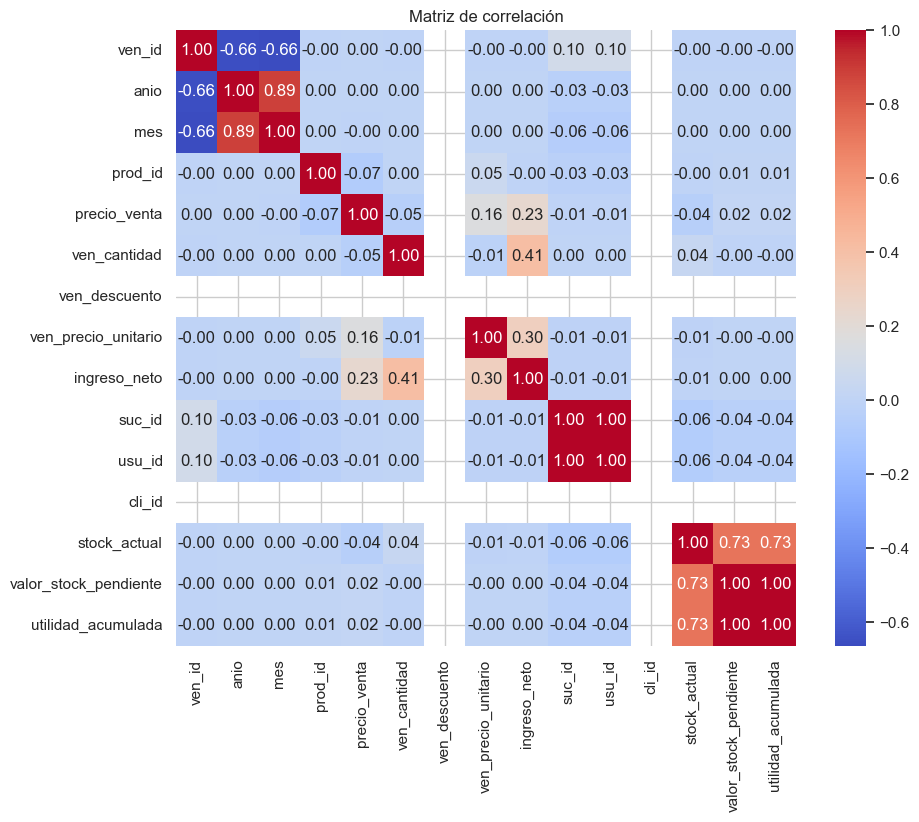

In [16]:
# Correlación numérica
num = df.select_dtypes(include=[np.number])
if num.shape[1] >= 2:
    corr = num.corr()
    display(corr)
    try:
        plt.figure(figsize=(10,8))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
        plt.title('Matriz de correlación')
        plt.show()
    except Exception as e:
        print('No se pudo graficar la correlación:', e)
else:
    print('No hay suficientes columnas numéricas para calcular correlación')

### 🔗 Análisis de Correlación: Colinealidad Crítica

---

El enfoque se centra en las relaciones más fuertes ($|r| \ge 0.70$), las cuales indican redundancia de información (**colinealidad**) entre las variables numéricas.

#### Correlaciones Fuertes Lógicas

| Variables | Correlación ($r$) | Tipo | Implicación |
| :--- | :--- | :--- | :--- |
| **stock\_actual** vs **valor\_stock\_pendiente** | $0.73$ | Fuerte (+) | Lógica: El volumen de inventario (`stock\_actual`) está fuertemente relacionado con su valor monetario (`valor\_stock\_pendiente`). |
| **stock\_actual** vs **utilidad\_acumulada** | $0.73$ | Fuerte (+) | Lógica: Un mayor volumen de *stock* implica un mayor valor potencial de utilidad. |
| **anio** vs **mes** | $0.89$ | Muy Fuerte (+) | Se espera esta relación en series temporales no completas, donde los valores de *mes* y *año* avanzan juntos.

#### Relaciones Moderadas y Relevantes

Estas relaciones son clave para entender el comportamiento de las ventas:

* **`ven_cantidad` vs `ingreso_neto` ($r = 0.41$):** Moderada, positiva. El volumen de unidades vendidas es un impulsor significativo del ingreso total.
* **`ven_precio\_unitario` vs `ingreso_neto` ($r = 0.30$):** Moderada, positiva. Los productos con precio unitario más alto también contribuyen a un mayor ingreso total.

#### Resumen de Acciones de Limpieza Estructural

Se recomienda realizar las siguientes acciones antes de iniciar cualquier modelo:

1.  **Eliminar Redundancia Total:** Descartar `ven_descuento`, `cli_id`, y las variables redundantes (`usu_id` y `valor_stock_pendiente`, por ejemplo).
2.  **Validar Insumos:** Las variables clave que determinan el ingreso neto son `ven_cantidad` y `ven_precio_unitario`.

La colinealidad perfecta entre variables clave requiere **eliminar las redundancias** antes de cualquier análisis predictivo. Se debe proceder a **descartar** `usu_id` (o `suc_id`) y `valor_stock_pendiente` (o `utilidad_acumulada`).

## Conclusión de la Fase 02 — Data Understanding

Resumen ejecutivo de hallazgos y recomendaciones finales:

- Alcance del dataset: el CSV bruto contiene transacciones con columnas clave: `ven_id`, `fecha_venta`, `anio`, `mes`, `dia_semana`, `prod_id`, `prod_nom`, `prod_marca`, `categoria`, `precio_venta`, `ven_cantidad`, `ven_descuento`, `ven_precio_unitario`, `ingreso_neto`, `suc_id`, `sucursal`, `usu_id`, `vendedor`, `cli_id`, `cliente`, `stock_actual`, `valor_stock_pendiente`, `utilidad_acumulada`.
- Volumen y memoria: el archivo es de gran tamaño (decenas/centenares de miles de filas); se verificó el uso de memoria y se recomendó convertir columnas repetitivas a `category` para eficiencia.
- Calidad y nulos: existen columnas con porcentajes de nulos (revisar tabla `missing`). Algunas columnas críticas presentan nulos que requieren estrategia (imputación, categoría "Desconocido", o revisión de la extracción).
- Tipos y consistencia: se normalizó la columna `fecha_venta` a datetime; se detectaron columnas con tipos `object` que podrían necesitar conversión a numérico para análisis posterior.
- Outliers y valores extremos: `precio_venta` e `ingreso_neto` presentan valores fuera del rango típico (ver quantiles p95/p99). Es necesario revisar los top outliers para distinguir errores de transacciones legítimas.
- Distribuciones categóricas: se detectaron etiquetas no uniformes (p.ej. "NO POSEE", "Sin Categoria"); es recomendable normalizar strings, agrupar categorías de baja frecuencia y corregir inconsistencias antes de modelar.
- Top productos y Pareto: una fracción reducida de productos concentra gran parte del ingreso — priorizar estos para análisis de precios, margen y reposición.
- Series temporales: la serie de `ingreso_neto` permite construir features temporales (dayofweek, month, rolling 7/30/90) y muestra patrones que deben explorarse con mayor detalle en preparación.
- Inventario y riesgo: la heurística `risk_score = total_ventas / stock_actual` identifica productos en riesgo de quiebre; estos deben validarse con lead time y datos de reposición para definir políticas de reorder.
- Correlaciones: se calculó la matriz de correlación entre variables numéricas; si existen pares altamente correlacionados, evaluar reducción de dimensionalidad o selección de features.

Recomendaciones inmediatas (priorizadas):
1. Implementar limpieza y casting de tipos en `03_Data_Preparation`: normalizar strings, convertir tipos numéricos, y crear `category` donde convenga.
2. Definir e implementar reglas de tratamiento para missing y outliers (documentadas y reproducibles).
3. Exportar resúmenes útiles a `03_Data_Preparation/intermedio/`: `missing.csv`, `top_products.csv`, `num_stats.csv`, `correlation.csv`.
4. Generar features temporales y ventanas (7/30/90 días) por `prod_id` para alimentar el modelado de demanda.
5. Validar y priorizar productos con alto `risk_score` para acciones operativas (reposición urgente, revisión de precios).
6. Preparar conjuntos `procesado` listos para modelado, ejecutar experimentos en la fase 04 y validar según los criterios de éxito definidos en la fase 01.

Comentarios finales:
- La fase de Data Understanding proporciona la evidencia y las decisiones necesarias para comenzar la preparación de datos con seguridad. Con las acciones recomendadas, el proyecto estará listo para avanzar a modelado con conjuntos más limpios, eficientes y explicables.